# Task 2 – Simple Linear Regression

**Goal:** Predict California median house values from a single feature — median household income.

**Why this dataset?**  
The California Housing dataset is a classic regression benchmark. Median income (`MedInc`) has the strongest linear relationship with house price, making it an ideal single-predictor to demonstrate how linear regression works.

**Metric:** R² (how much variance the model explains) and MSE (average squared prediction error).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## 1. Load & Inspect the Dataset

In [2]:
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

print(f"Dataset shape: {df.shape}")
print(f"\nFeature descriptions:\n{housing.DESCR[:800]}")
df.head()

Dataset shape: (20640, 9)

Feature descriptions:
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 2. Pick the Feature & Split

For *simple* regression we use one predictor. `MedInc` (median income in tens of thousands) has the highest correlation with house value — a natural starting point.

In [3]:
X = df[['MedInc']]   # double brackets → keeps it as a DataFrame (2D)
y = df['MedHouseVal']

print(f"Correlation with target: {df['MedInc'].corr(df['MedHouseVal']):.4f}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train)} rows  |  Test: {len(X_test)} rows")

Correlation with target: 0.6881
Train: 16512 rows  |  Test: 4128 rows


## 3. Train the Model

In [4]:
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Coefficient (slope) : {model.coef_[0]:.4f}")
print(f"Intercept           : {model.intercept_:.4f}")
print("\nInterpretation: for every 1-unit increase in median income,")
print(f"house value is predicted to rise by ~${model.coef_[0]*100_000:,.0f}.")

Coefficient (slope) : 0.4193
Intercept           : 0.4446

Interpretation: for every 1-unit increase in median income,
house value is predicted to rise by ~$41,934.


## 4. Evaluate

In [5]:
y_pred = model.predict(X_test)

r2  = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R² Score : {r2:.4f}  — the model explains {r2*100:.1f}% of variance in house prices")
print(f"MSE      : {mse:.4f}")
print(f"RMSE     : {rmse:.4f}  (in units of $100k)")

R² Score : 0.4589  — the model explains 45.9% of variance in house prices
MSE      : 0.7091
RMSE     : 0.8421  (in units of $100k)


## 5. Visualise the Regression Line

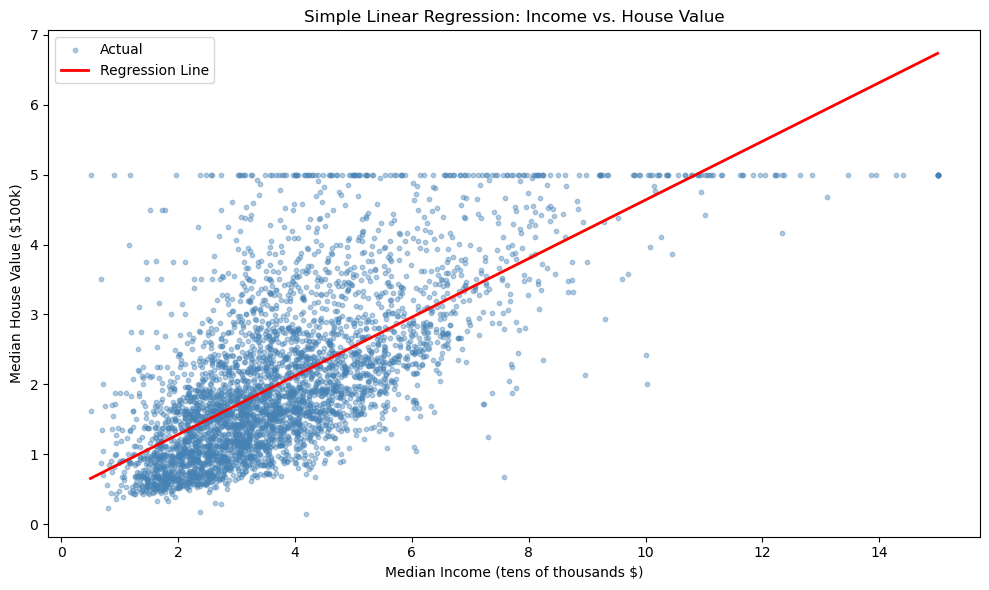

In [6]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='steelblue', alpha=0.4, s=10, label='Actual')
plt.plot(X_test.sort_values('MedInc'),
         model.predict(X_test.sort_values('MedInc')),
         color='red', linewidth=2, label='Regression Line')
plt.xlabel('Median Income (tens of thousands $)')
plt.ylabel('Median House Value ($100k)')
plt.title('Simple Linear Regression: Income vs. House Value')
plt.legend()
plt.tight_layout()
plt.show()